In [12]:
import torch
import torchaudio
from pathlib import Path

from audio_classification_playground.beats.BEATs import BEATs, BEATsConfig


# -----------------------------
# Configuration terminology
# -----------------------------
#
# context_len_sec:
#   Total duration passed into BEATs for one prediction.
#
# target_len_sec:
#   The inner time span that we ATTRIBUTE the prediction to.
#   This is centered inside the wider context window.
#
# hop_len_sec:
#   Time spacing between adjacent emitted predictions.
#
# Example defaults:
#   context_len_sec = 2.0
#   target_len_sec  = 0.5
#   hop_len_sec     = 0.25
#


In [13]:

def load_beats_classifier(checkpoint_path: str):
    device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
    checkpoint = torch.load(checkpoint_path, map_location=device)

    cfg = BEATsConfig(checkpoint["cfg"])
    model = BEATs(cfg)
    model.load_state_dict(checkpoint["model"])
    model.eval().to(device)

    label_dict = checkpoint.get("label_dict")
    return model, label_dict, checkpoint["cfg"]


def load_audio_mono_16k(audio_path: str, target_sr: int = 16000):
    wav, sr = torchaudio.load(audio_path)

    # Convert to mono if needed
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)

    # Resample if needed
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
        sr = target_sr

    return wav.squeeze(0), sr



In [19]:
def run_sliding_attribution(
    audio_path: str,
    checkpoint_path: str,
    context_len_sec: float = 2.0,
    target_len_sec: float = 0.5,
    hop_len_sec: float = 0.25,
    top_k: int = 5,
    device: str = "cpu",
):
    """
    Returns dense clip-level predictions attributed to centered target spans.

    For each emitted prediction:
      - model sees: [context_start, context_end]
      - prediction is attributed to: [target_start, target_end]
      - target span is centered within the context span
    """

    if target_len_sec > context_len_sec:
        raise ValueError("target_len_sec must be <= context_len_sec")

    model, label_dict, cfg = load_beats_classifier(checkpoint_path)
    wav, sr = load_audio_mono_16k(audio_path, target_sr=16000)

    context_len_samples = int(round(context_len_sec * sr))
    target_len_samples = int(round(target_len_sec * sr))
    hop_len_samples = int(round(hop_len_sec * sr))

    audio_len_samples = wav.shape[0]
    audio_len_sec = audio_len_samples / sr

    # Center offset of the target span inside the context span
    target_offset_samples = (context_len_samples - target_len_samples) // 2

    results = []

    # We iterate over context windows.
    # Each context window produces one prediction.
    # That prediction is attributed to the centered target span.
    context_start = 0

    while context_start < audio_len_samples:
        context_end = context_start + context_len_samples

        chunk = wav[context_start:context_end]

        # Pad final chunk if shorter than full context length
        if chunk.shape[0] < context_len_samples:
            pad_amount = context_len_samples - chunk.shape[0]
            chunk = torch.nn.functional.pad(chunk, (0, pad_amount))

        audio_input = chunk.unsqueeze(0).to(device)  # shape: [1, T]

        with torch.no_grad():
            probs, _ = model.extract_features(audio_input)

        probs = probs[0].detach().cpu()

        k = min(top_k, probs.numel())
        top_scores, top_indices = torch.topk(probs, k=k)

        # Attribution span centered inside context
        target_start = context_start + target_offset_samples
        target_end = target_start + target_len_samples

        # Clamp to actual audio duration
        target_start_sec = max(0.0, target_start / sr)
        target_end_sec = min(audio_len_sec, target_end / sr)
        context_start_sec = context_start / sr
        context_end_sec = min(audio_len_sec, context_end / sr)

        top_predictions = []
        for score, idx in zip(top_scores.tolist(), top_indices.tolist()):
            label = label_dict[idx] if label_dict is not None else str(idx)
            top_predictions.append(
                {
                    "label": label,
                    "score": float(score),
                }
            )

        results.append(
            {
                "context": {
                    "start_sec": context_start_sec,
                    "end_sec": context_end_sec,
                    "length_sec": context_len_sec,
                },
                "target": {
                    "start_sec": target_start_sec,
                    "end_sec": target_end_sec,
                    "length_sec": target_len_sec,
                },
                "top_predictions": top_predictions,
            }
        )

        context_start += hop_len_samples

    return {
        "audio_path": str(audio_path),
        "audio_duration_sec": audio_len_sec,
        "config": {
            "context_len_sec": context_len_sec,
            "target_len_sec": target_len_sec,
            "hop_len_sec": hop_len_sec,
            "sample_rate": sr,
            "input_patch_size": cfg["input_patch_size"],
            "token_stride_sec": cfg["input_patch_size"] * 0.01,
        },
        "windows": results,
    }


def print_prediction_summary(output, max_windows: int = 10):
    print("=== Sliding Attribution Summary ===")
    print(f"Audio: {output['audio_path']}")
    print(f"Duration: {output['audio_duration_sec']:.2f}s")
    print("Config:")
    for k, v in output["config"].items():
        print(f"  {k}: {v}")
    print()

    for i, item in enumerate(output["windows"][:max_windows]):
        c = item["context"]
        t = item["target"]
        preds = item["top_predictions"]

        print(f"Window {i}")
        print(
            f"  context = [{c['start_sec']:.2f}, {c['end_sec']:.2f}] "
            f"(len={c['length_sec']:.2f}s)"
        )
        print(
            f"  target  = [{t['start_sec']:.2f}, {t['end_sec']:.2f}] "
            f"(len={t['length_sec']:.2f}s)"
        )
        for pred in preds:
            print(f"    {pred['label']}: {pred['score']:.4f}")
        print()


In [35]:
audio_path = "/workspace/tmp_data/3d48c229-3505-4a40-b4d2-1e704aa0b8cc.mp3"
checkpoint_path = "/workspace/models/BEATs_iter3_plus_AS2M_finetuned_on_AS2M_cpt2.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

context_len_sec=2.0
target_len_sec=0.5
hop_len_sec=0.1


In [36]:
import torchaudio
wav,sr = torchaudio.load(audio_path)

In [37]:
model, label_dict, cfg = load_beats_classifier(checkpoint_path)
wav, sr = load_audio_mono_16k(audio_path, target_sr=16000)

context_len_samples = int(round(context_len_sec * sr))
target_len_samples = int(round(target_len_sec * sr))
hop_len_samples = int(round(hop_len_sec * sr))

audio_len_samples = wav.shape[0]
audio_len_sec = audio_len_samples / sr

# Center offset of the target span inside the context span
target_offset_samples = (context_len_samples - target_len_samples) // 2

/workspace/audio-classification-playground/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [38]:
import torchaudio.compliance.kaldi as ta_kaldi

# Step 1: fbank for the full signal — one call
full_fbank = ta_kaldi.fbank(
    wav.unsqueeze(0) * 2**15,
    num_mel_bins=128, sample_frequency=16000,
    frame_length=25, frame_shift=10,
)
full_fbank = (full_fbank - 15.41663) / (2 * 6.55582)
# shape: (total_frames, 128)  — one frame per 10ms

# Step 2: sliding-window slice using unfold (creates a *view*, no copy)
context_frames = int(context_len_sec / 0.01)   # 200 for 2.0s
hop_frames     = int(hop_len_sec / 0.01)        # 25  for 0.25s

fbank_windows = full_fbank.unfold(0, context_frames, hop_frames)
# shape: (N_windows, 128, context_frames)
fbank_windows = fbank_windows.permute(0, 2, 1).contiguous()
# shape: (N_windows, context_frames, 128)  — matches what the model expects

In [39]:
from tqdm.notebook import tqdm

# Step 3: batched forward — bypass preprocess, go straight into the model guts

all_probs = []
batch_size = 64

for b in tqdm(range(0, fbank_windows.shape[0], batch_size)):
    fbank_batch = fbank_windows[b : b + batch_size].to(device)

    with torch.no_grad():
        x = fbank_batch.unsqueeze(1)                          # (B, 1, T, 128)
        x = model.patch_embedding(x)                          # Conv2d
        x = x.reshape(x.shape[0], x.shape[1], -1)
        x = x.transpose(1, 2)
        x = model.layer_norm(x)
        if model.post_extract_proj is not None:
            x = model.post_extract_proj(x)
        x = model.dropout_input(x)
        x, _ = model.encoder(x, padding_mask=None)
        x = model.predictor_dropout(x)
        logits = model.predictor(x)
        logits = logits.mean(dim=1)
        probs = torch.sigmoid(logits)

    all_probs.append(probs.cpu())

score_matrix = torch.cat(all_probs, dim=0)  # (N_windows, 527)

  0%|          | 0/554 [00:00<?, ?it/s]

In [40]:
import numpy as np

target_offset_sec = (context_len_sec - target_len_sec) / 2
n_windows = score_matrix.shape[0]
target_starts = np.arange(n_windows) * hop_len_sec + target_offset_sec
target_ends = target_starts + target_len_sec

In [41]:
score_matrix.shape

torch.Size([35403, 527])

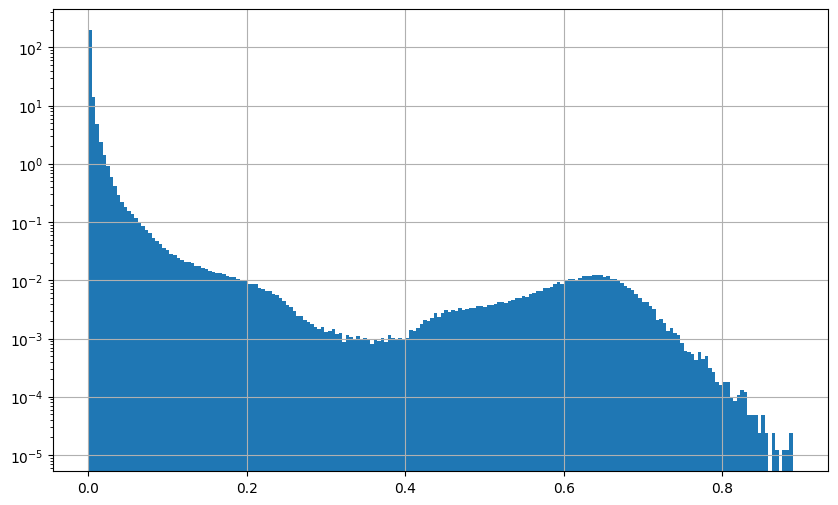

In [42]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(10, 6))
ax.hist(score_matrix.numpy().ravel(), bins=200, density=True)
ax.set_yscale('log')
ax.grid(True)
plt.show()

In [43]:
import json, urllib.request

url = "https://raw.githubusercontent.com/audioset/ontology/master/ontology.json"
ontology = json.loads(urllib.request.urlopen(url).read())

# MID → entry lookup
mid_to_entry = {e["id"]: e for e in ontology}

# Build parent map (invert child_ids)
mid_to_parents = {}
for e in ontology:
    for child_id in e.get("child_ids", []):
        mid_to_parents.setdefault(child_id, []).append(e["id"])

In [44]:
def get_hierarchy_paths(mid, mid_to_parents, mid_to_entry):
    """Returns all root-to-leaf paths for a given MID."""
    def _climb(m):
        parents = mid_to_parents.get(m, [])
        if not parents:
            return [[m]]
        paths = []
        for p in parents:
            for path in _climb(p):
                paths.append(path + [m])
        return paths

    paths = _climb(mid)
    return [
        [mid_to_entry[m]["name"] for m in path]
        for path in paths
    ]

In [45]:
threshold = 0.4

# score_matrix: (N_windows, 527) from your batched inference
# label_dict: {int_index: mid_string} from checkpoint

max_scores = score_matrix.max(dim=0).values  # (527,)
passing_indices = (max_scores >= threshold).nonzero(as_tuple=True)[0]

for idx in passing_indices:
    idx = idx.item()
    mid = label_dict[idx]
    entry = mid_to_entry.get(mid, {})
    name = entry.get("name", mid)
    score = max_scores[idx].item()

    print(f"\n{name} ({mid})  —  max score: {score:.4f}")
    for path in get_hierarchy_paths(mid, mid_to_parents, mid_to_entry):
        print(f"  {'  >  '.join(path)}")


Music (/m/04rlf)  —  max score: 0.8818
  Music

Guitar (/m/0342h)  —  max score: 0.4587
  Music  >  Musical instrument  >  Plucked string instrument  >  Guitar

Musical instrument (/m/04szw)  —  max score: 0.5277
  Music  >  Musical instrument

Plucked string instrument (/m/0fx80y)  —  max score: 0.4177
  Music  >  Musical instrument  >  Plucked string instrument

Speech (/m/09x0r)  —  max score: 0.8893
  Human sounds  >  Human voice  >  Speech

Sigh (/m/07plz5l)  —  max score: 0.7588
  Human sounds  >  Human voice  >  Sigh

Beatboxing (/m/02cz_7)  —  max score: 0.6800
  Music  >  Music genre  >  Hip hop music  >  Beatboxing
  Music  >  Music genre  >  Vocal music  >  Beatboxing

Throat clearing (/m/0dl9sf8)  —  max score: 0.6183
  Human sounds  >  Respiratory sounds  >  Cough  >  Throat clearing

Speech synthesizer (/m/0brhx)  —  max score: 0.6694
  Human sounds  >  Human voice  >  Speech  >  Speech synthesizer

Cough (/m/01b_21)  —  max score: 0.6516
  Human sounds  >  Respiratory s

In [53]:
import numpy as np

# --- 1. Collect all descendants of a subtree (inclusive) ---
def get_all_descendants(mid, mid_to_entry):
    result = {mid}
    for child in mid_to_entry.get(mid, {}).get("child_ids", []):
        result |= get_all_descendants(child, mid_to_entry)
    return result

human_sounds_mids = get_all_descendants("/m/0dgw9r", mid_to_entry)
speech_mids = get_all_descendants("/m/09x0r", mid_to_entry)

target_mids = human_sounds_mids - speech_mids

# Intersect with model's 527 classes (abstract nodes won't be in label_dict)
mid_to_idx = {mid: idx for idx, mid in label_dict.items()}
target_classes = {
    mid: mid_to_idx[mid]
    for mid in target_mids
    if mid in mid_to_idx
}

print(f"{len(target_classes)} classes kept out of {len(human_sounds_mids)} Human Sounds descendants")
print(f"({len(speech_mids)} Speech subtree entries excluded)")

# --- 2. Find contiguous segments above threshold ---
def find_contiguous_segments(scores_col, threshold, target_starts, target_ends):
    above = (scores_col >= threshold).numpy().astype(int)
    diff = np.diff(above, prepend=0, append=0)
    seg_starts = np.where(diff == 1)[0]
    seg_ends = np.where(diff == -1)[0]

    segments = []
    for s, e in zip(seg_starts, seg_ends):
        seg_scores = scores_col[s:e]
        segments.append({
            "start_sec": float(target_starts[s]),
            "end_sec": float(target_ends[e - 1]),
            "max_score": seg_scores.max().item(),
            "mean_score": seg_scores.mean().item(),
            "n_windows": int(e - s),
        })
    return segments

# --- 3. Run for all target classes ---
threshold = 0.3

all_segments = {}
for mid, idx in target_classes.items():
    name = mid_to_entry[mid]["name"]
    scores_col = score_matrix[:, idx]
    segments = find_contiguous_segments(scores_col, threshold, target_starts, target_ends)
    if segments:
        all_segments[name] = segments

# --- 4. Display ---
def fmt_time(seconds):
    mins = int(seconds // 60)
    secs = int(seconds % 60)
    ms = int(round((seconds % 1) * 1000))
    return f"{mins:02d}:{secs:02d}:{ms:03d}"

for name in sorted(all_segments, key=lambda n: len(all_segments[n]), reverse=True):
    segments = all_segments[name]
    total_dur = sum(s["end_sec"] - s["start_sec"] for s in segments)
    print(f"\n{name}  —  {len(segments)} segment(s), {fmt_time(total_dur)} total")
    for seg in segments:
        dur = seg["end_sec"] - seg["start_sec"]
        print(
            f"  [{fmt_time(seg['start_sec'])} – {fmt_time(seg['end_sec'])}]"
            f"  dur={fmt_time(dur)}"
            f"  max={seg['max_score']:.3f}"
            f"  mean={seg['mean_score']:.3f}"
            f"  ({seg['n_windows']} wins)"
        )

64 classes kept out of 83 Human Sounds descendants
(8 Speech subtree entries excluded)

Cough  —  41 segment(s), 00:27:400 total
  [05:39:250 – 05:39:850]  dur=00:00:600  max=0.394  mean=0.384  (2 wins)
  [05:39:550 – 05:40:650]  dur=00:01:100  max=0.581  mean=0.491  (7 wins)
  [05:40:450 – 05:40:950]  dur=00:00:500  max=0.323  mean=0.323  (1 wins)
  [05:40:750 – 05:41:250]  dur=00:00:500  max=0.336  mean=0.336  (1 wins)
  [05:57:350 – 05:59:450]  dur=00:02:100  max=0.652  mean=0.539  (17 wins)
  [07:42:950 – 07:44:050]  dur=00:01:100  max=0.464  mean=0.367  (7 wins)
  [07:43:750 – 07:45:350]  dur=00:01:600  max=0.584  mean=0.447  (12 wins)
  [08:56:650 – 08:57:150]  dur=00:00:500  max=0.306  mean=0.306  (1 wins)
  [09:41:150 – 09:42:550]  dur=00:01:400  max=0.471  mean=0.398  (10 wins)
  [09:42:250 – 09:42:850]  dur=00:00:600  max=0.522  mean=0.411  (2 wins)
  [16:19:450 – 16:19:950]  dur=00:00:500  max=0.308  mean=0.308  (1 wins)
  [17:05:450 – 17:06:650]  dur=00:01:200  max=0.498  m

In [52]:
speech_mids = get_all_descendants("/m/09x0r", mid_to_entry)

# All model classes EXCEPT Speech subtree
target_classes = {
    mid: idx
    for idx, mid in label_dict.items()
    if mid not in speech_mids
}

print(f"{len(target_classes)} classes kept, {len(label_dict) - len(target_classes)} Speech classes excluded")


# --- 2. Find contiguous segments above threshold ---
def find_contiguous_segments(scores_col, threshold, target_starts, target_ends):
    above = (scores_col >= threshold).numpy().astype(int)
    diff = np.diff(above, prepend=0, append=0)
    seg_starts = np.where(diff == 1)[0]
    seg_ends = np.where(diff == -1)[0]

    segments = []
    for s, e in zip(seg_starts, seg_ends):
        seg_scores = scores_col[s:e]
        segments.append({
            "start_sec": float(target_starts[s]),
            "end_sec": float(target_ends[e - 1]),
            "max_score": seg_scores.max().item(),
            "mean_score": seg_scores.mean().item(),
            "n_windows": int(e - s),
        })
    return segments

# --- 3. Run for all target classes ---
threshold = 0.4

all_segments = {}
for mid, idx in target_classes.items():
    name = mid_to_entry[mid]["name"]
    scores_col = score_matrix[:, idx]
    segments = find_contiguous_segments(scores_col, threshold, target_starts, target_ends)
    if segments:
        all_segments[name] = segments

# --- 4. Display ---
def fmt_time(seconds):
    mins = int(seconds // 60)
    secs = int(seconds % 60)
    ms = int(round((seconds % 1) * 1000))
    return f"{mins:02d}:{secs:02d}:{ms:03d}"

for name in sorted(all_segments, key=lambda n: len(all_segments[n]), reverse=True):
    segments = all_segments[name]
    total_dur = sum(s["end_sec"] - s["start_sec"] for s in segments)
    print(f"\n{name}  —  {len(segments)} segment(s), {fmt_time(total_dur)} total")
    for seg in segments:
        dur = seg["end_sec"] - seg["start_sec"]
        print(
            f"  [{fmt_time(seg['start_sec'])} – {fmt_time(seg['end_sec'])}]"
            f"  dur={fmt_time(dur)}"
            f"  max={seg['max_score']:.3f}"
            f"  mean={seg['mean_score']:.3f}"
            f"  ({seg['n_windows']} wins)"
        )

519 classes kept, 8 Speech classes excluded

Music  —  19 segment(s), 02:16:900 total
  [00:00:750 – 00:27:750]  dur=00:27:000  max=0.838  mean=0.608  (266 wins)
  [02:16:350 – 02:31:250]  dur=00:14:900  max=0.882  mean=0.619  (145 wins)
  [02:30:950 – 02:31:450]  dur=00:00:500  max=0.438  mean=0.438  (1 wins)
  [02:32:550 – 02:33:050]  dur=00:00:500  max=0.406  mean=0.406  (1 wins)
  [30:12:550 – 30:25:850]  dur=00:13:300  max=0.852  mean=0.677  (129 wins)
  [35:20:750 – 35:28:150]  dur=00:07:400  max=0.808  mean=0.662  (70 wins)
  [37:08:450 – 37:08:950]  dur=00:00:500  max=0.421  mean=0.421  (1 wins)
  [39:29:850 – 39:50:350]  dur=00:20:500  max=0.826  mean=0.657  (201 wins)
  [39:50:150 – 39:50:650]  dur=00:00:500  max=0.451  mean=0.451  (1 wins)
  [39:50:450 – 39:50:950]  dur=00:00:500  max=0.409  mean=0.409  (1 wins)
  [39:50:750 – 39:51:250]  dur=00:00:500  max=0.410  mean=0.410  (1 wins)
  [39:51:450 – 39:52:050]  dur=00:00:600  max=0.427  mean=0.416  (2 wins)
  [39:51:950 – 39

In [51]:
# Check if the MID is even in the model's label_dict
laughter_mid = "/m/01j3sz"
print("All label_dict entries containing 'j3sz':")
for idx, mid in label_dict.items():
    if "j3sz" in mid:
        print(f"  index {idx} → {mid}")

# Also check: what index did we actually plot?
print(f"\nmid_to_idx lookup for {laughter_mid}: {mid_to_idx.get(laughter_mid, 'NOT FOUND')}")

# If you know a timestamp (in minutes) where laughter occurs,
# check what the model's top classes are there:
t_min = 5.95  # ← replace with a time you KNOW has laughter
window_idx = int(t_min * 60 / hop_len_sec)
top_scores, top_indices = torch.topk(score_matrix[window_idx], k=15)
print(f"\nTop 15 classes at t={t_min:.1f}min (window {window_idx}):")
for score, idx in zip(top_scores.tolist(), top_indices.tolist()):
    mid = label_dict[idx]
    name = mid_to_entry.get(mid, {}).get("name", mid)
    print(f"  {score:.4f}  {name} ({mid})")

All label_dict entries containing 'j3sz':
  index 472 → /m/01j3sz

mid_to_idx lookup for /m/01j3sz: 472

Top 15 classes at t=6.0min (window 3570):
  0.7799  Speech (/m/09x0r)
  0.6159  Cough (/m/01b_21)
  0.3571  Throat clearing (/m/0dl9sf8)
  0.0634  Inside, small room (/t/dd00125)
  0.0185  Music (/m/04rlf)
  0.0167  Male speech, man speaking (/m/05zppz)
  0.0163  Sigh (/m/07plz5l)
  0.0101  Silence (/m/028v0c)
  0.0079  Narration, monologue (/m/02qldy)
  0.0056  Sneeze (/m/01hsr_)
  0.0055  Speech synthesizer (/m/0brhx)
  0.0048  Breathing (/m/0lyf6)
  0.0039  Laughter (/m/01j3sz)
  0.0037  Sound effect (/m/0c1dj)
  0.0028  Musical instrument (/m/04szw)


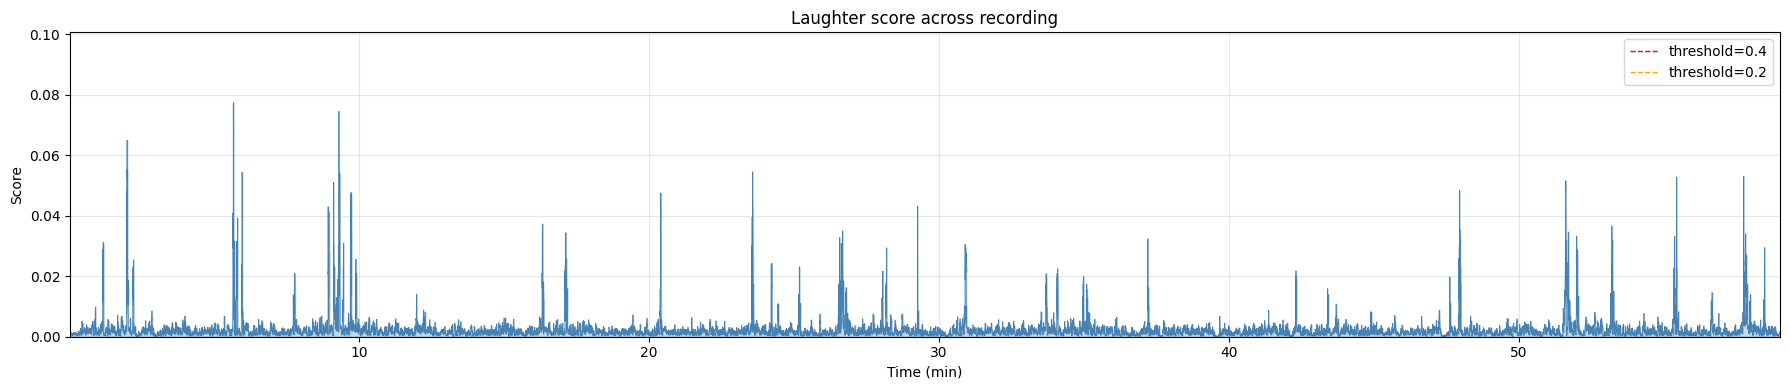

max=0.0774  mean=0.0022  windows >= 0.4: 0  windows >= 0.2: 0  windows >= 0.1: 0


In [49]:
import matplotlib.pyplot as plt

laughter_mid = "/m/01j3sz"
idx = mid_to_idx[laughter_mid]
scores = score_matrix[:, idx].numpy()

# Time axis (center of each target window)
time_min = (target_starts + target_len_sec / 2) / 60

fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(time_min, scores, linewidth=0.5, color="steelblue")
ax.axhline(y=0.4, color="red", linestyle="--", linewidth=1, label="threshold=0.4")
ax.axhline(y=0.2, color="orange", linestyle="--", linewidth=1, label="threshold=0.2")
ax.fill_between(time_min, scores, alpha=0.3, color="steelblue")

ax.set_xlabel("Time (min)")
ax.set_ylabel("Score")
ax.set_title("Laughter score across recording")
ax.set_xlim(time_min[0], time_min[-1])
ax.set_ylim(0, min(1.0, scores.max() * 1.3))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"max={scores.max():.4f}  mean={scores.mean():.4f}  "
      f"windows >= 0.4: {(scores >= 0.4).sum()}  "
      f"windows >= 0.2: {(scores >= 0.2).sum()}  "
      f"windows >= 0.1: {(scores >= 0.1).sum()}")

In [ ]:

# output = run_sliding_attribution(
#     audio_path=audio_path,
#     checkpoint_path=checkpoint_path,
#     context_len_sec=2.0,
#     target_len_sec=0.5,
#     hop_len_sec=0.25,
#     top_k=5,
#     device=device,
# )

# print_prediction_summary(output, max_windows=12)

/workspace/audio-classification-playground/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


=== Sliding Attribution Summary ===
Audio: /workspace/tmp_data/3d48c229-3505-4a40-b4d2-1e704aa0b8cc.mp3
Duration: 3542.31s
Config:
  context_len_sec: 2.0
  target_len_sec: 0.5
  hop_len_sec: 0.25
  sample_rate: 16000
  input_patch_size: 16
  token_stride_sec: 0.16

Window 0
  context = [0.00, 2.00] (len=2.00s)
  target  = [0.75, 1.25] (len=0.50s)
    /m/04rlf: 0.7986
    /m/05fw6t: 0.1783
    /m/09x0r: 0.1055
    /t/dd00121: 0.0937
    /m/01sm1g: 0.0864

Window 1
  context = [0.25, 2.25] (len=2.00s)
  target  = [1.00, 1.50] (len=0.50s)
    /m/04rlf: 0.5354
    /m/09x0r: 0.1831
    /m/028v0c: 0.1484
    /m/0l14md: 0.0963
    /m/026t6: 0.0852

Window 2
  context = [0.50, 2.50] (len=2.00s)
  target  = [1.25, 1.75] (len=0.50s)
    /m/04rlf: 0.4667
    /m/09x0r: 0.3197
    /m/028v0c: 0.1361
    /m/0l14md: 0.0469
    /m/04szw: 0.0441

Window 3
  context = [0.75, 2.75] (len=2.00s)
  target  = [1.50, 2.00] (len=0.50s)
    /m/04rlf: 0.4948
    /m/09x0r: 0.3726
    /m/028v0c: 0.1822
    /m/04szw